In [3]:
from IPython.display import Image,display
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

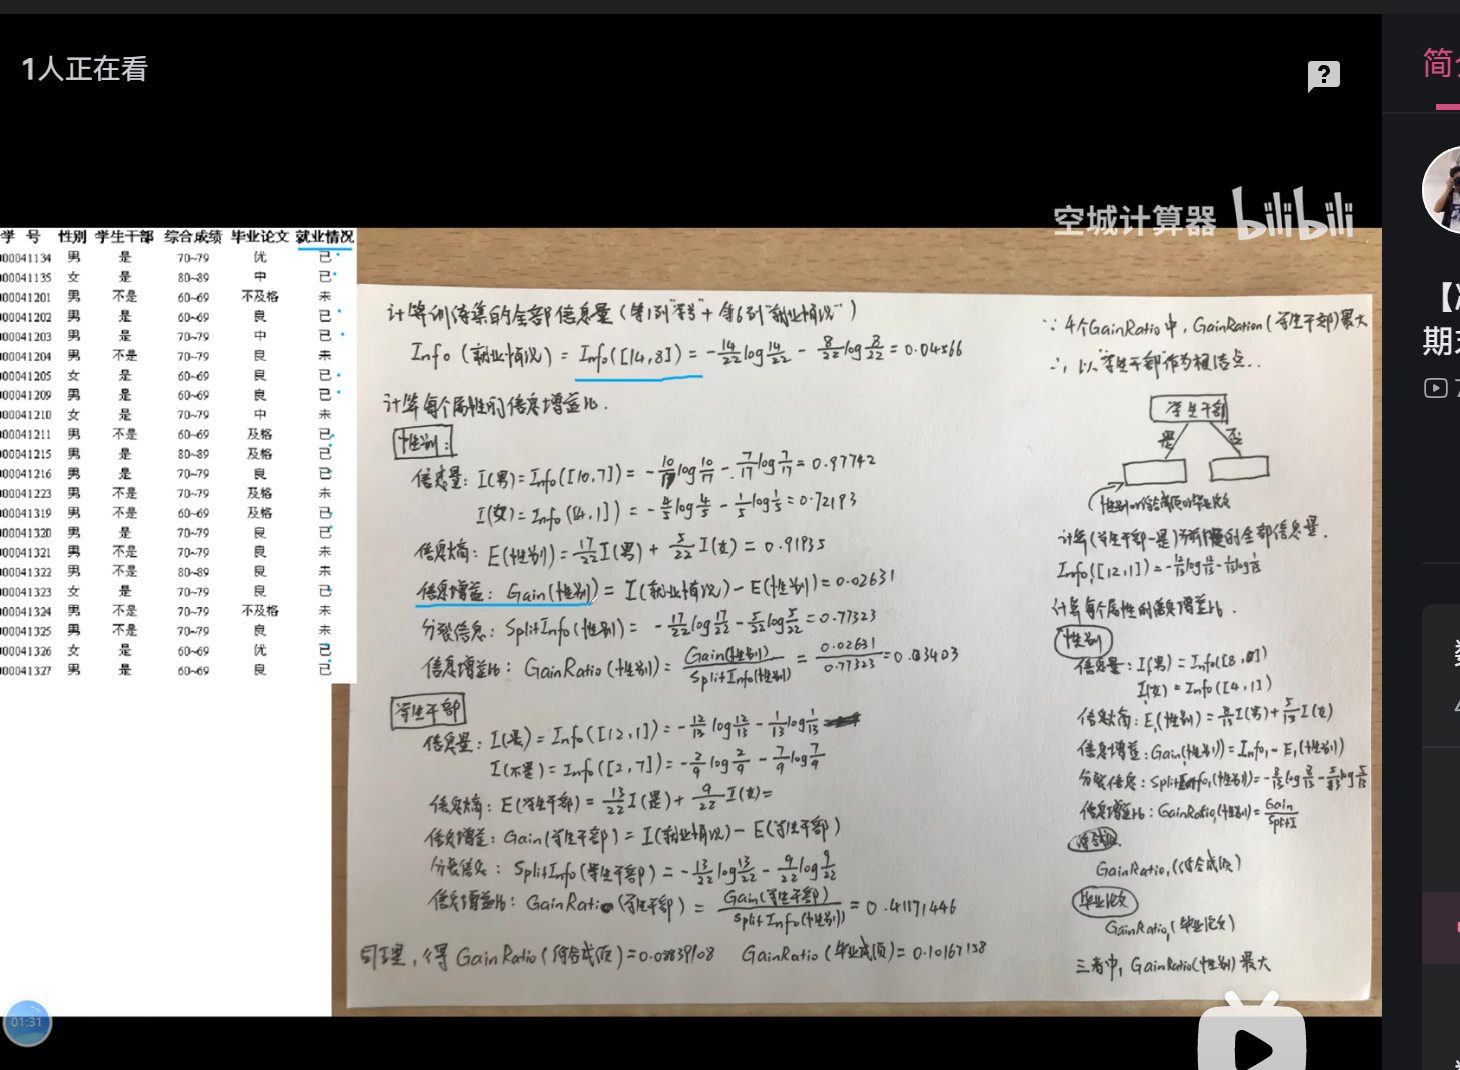

In [10]:
display(Image(filename="10-相关计算.png"))

In [11]:
df_train=pd.read_csv("c45_loan_train.csv")
df_test=pd.read_csv("c45_loan_test.csv")
df=df_train.copy()

x_cols=df.drop(['id','approved'],axis=1).columns.to_list()
c_cols=['age','income_k','credit_score','debt_ratio']
y_col='approved'

def calculate_entropy(series:pd.Series)->float:
    if len(series)==0:
        return 0.0
    prob=series.value_counts(normalize=True)
    entropy=-np.sum(prob*np.log2(prob))
    return float(entropy)

def calculate_conditional_entropy(df:pd.DataFrame,x_col:str,y_col:str)->float:
    prob_xi=df[x_col].value_counts(normalize=True)
    group_entropy=df.groupby(x_col)[y_col].apply(calculate_entropy)
    conditional_entropy=np.sum(prob_xi*group_entropy)
    return float(conditional_entropy)

def calculate_splitinfo(df:pd.DataFrame,x_col:str)->float:
    prob_xi=df[x_col].value_counts(normalize=True)
    #分母0情况
    if len(prob_xi)<=1:
        return 0.0
    splitinfo=-np.sum(prob_xi*np.log2(prob_xi))
    return float(splitinfo)

def info_gain(base_entropy:float,df:pd.DataFrame,x_col:str,y_col:str)->float:
    return float(base_entropy-calculate_conditional_entropy(df,x_col,y_col))
    

def info_gain_ratio(base_entropy:float,df:pd.DataFrame,x_col:str,y_col:str)->float:
    gain=info_gain(base_entropy,df,x_col,y_col)
    splitinfo=calculate_splitinfo(df,x_col)
    if splitinfo==0.0:
        return 0.0
    gain_ratio=gain/splitinfo
    return float(gain_ratio)

def best_split_for_continuous_var(
    df:pd.DataFrame,
    x_col:str,
    y_col:str,
    base_entropy:float
):
    sorted_series=df[x_col].sort_values().unique()
    if len(sorted_series)<=1:
        return None,0.0,0.0
    candidate_splits=(sorted_series[:-1]+sorted_series[1:])/2.0
    best_split_point=None
    max_gain=-1.0
    best_ratio=0.0
    for t in candidate_splits:
        temp_binary=(df[x_col]>t).astype(int)
        temp_df=pd.DataFrame({
            'temp_x':temp_binary,
            'y':df[y_col]
        })
        gain=info_gain(base_entropy,temp_df,'temp_x','y')
        if gain>max_gain:
            max_gain=gain
            best_split_point=t
            best_ratio=info_gain_ratio(base_entropy,temp_df,'temp_x','y')

    return best_split_point,max_gain,best_ratio
        

def is_continuous(series: pd.Series) -> bool:
    # 1. 拦截布尔类型
    if pd.api.types.is_bool_dtype(series):
        return False

    # 2. 拦截字符串、类别型
    if pd.api.types.is_object_dtype(series) or isinstance(
        series.dtype, pd.CategoricalDtype
    ):
        return False

    # 3. 核心拦截：即使是 int/float，如果去重后的取值个数 <= 2
    # （比如只有 0和1，或者这一列全部都是同一个数字），它本质上就是离散的，或者无意义的
    if series.nunique() <= 2:
        return False

    # 4. 确保是数值型
    return pd.api.types.is_numeric_dtype(series)

class TreeNode:
    def __init__(
        self,
        is_leaf=False,
        feature=None,
        prediction=None,
        is_continuous=False,
        split_point=None
    ):
        self.is_leaf=is_leaf
        self.feature=feature
        self.prediction=prediction
        self.is_continuous=is_continuous
        self.split_point=split_point
        self.children={}
        
    def display(self, indent="", branch_name=""):
        """递归打印整棵决策树"""
        # 1. 组装当前分支的前缀修饰
        prefix = f"[{branch_name}] -> " if branch_name else ""

        # 2. 如果是叶子节点，打印预测结果
        if self.is_leaf:
            print(f"{indent}{prefix}🍃 Leaf: Predict -> {self.prediction}")
            return

        # 3. 如果是内部节点，打印当前节点的划分特征
        if self.is_continuous:
            print(
                f"{indent}{prefix}🌲 Internal Node: <{self.feature}> (Split at {self.split_point:.4f})"
            )
        else:
            print(f"{indent}{prefix}🌲 Internal Node: <{self.feature}>")

        # 4. 递归打印所有子节点
        # 为了美观，计算下一层的缩进
        next_indent = indent + "    "
        for key, child_node in self.children.items():
            # 针对连续值的 key 做一下更人性化的转换展示
            if self.is_continuous:
                if key == "less_or_equal":
                    friendly_key = f"<= {self.split_point:.4f}"
                elif key == "greater":
                    friendly_key = f"> {self.split_point:.4f}"
                else:
                    friendly_key = key
            else:
                friendly_key = str(key)

            # 递归调用子节点的展示
            child_node.display(next_indent, branch_name=friendly_key)
    def predict(self,sample:dict):
        current_node=self
        while not current_node.is_leaf:
            feat=current_node.feature
            val=sample.get(feat)
            if current_node.is_continuous:
                if val is None:
                    return "erreo:missing continuous feature value"
                if val<=current_node.split_point:
                    current_node=current_node.children['less_or_equal']
                else:
                    current_node=current_node.children['greater']
            else:
                if val not in current_node.children:
                    return"error:unknown feature value"
                current_node=current_node.children[val]
        return current_node.prediction

def build_tree(
    df:pd.DataFrame,
    feature:list,
    target_col:str,
    continuous_feature:list=None,
    entropy_threshold:float=0.1
)->TreeNode:

    if len(df)==0:
        return TreeNode(is_leaf=True,prediction=None)
        
    base_entropy=calculate_entropy(df[target_col])
    unique_targets=df[target_col].unique()
    if len(unique_targets)<=1:
        return TreeNode(is_leaf=True,prediction=unique_targets[0])#?if empty
    
    if base_entropy<entropy_threshold:
        most_common=df[target_col].mode()[0]
        return TreeNode(is_leaf=True,prediction=most_common)

    if len(feature)<=0:
        most_common=df[target_col].mode()[0]
        return TreeNode(is_leaf=True,prediction=most_common)

    #递归
    if continuous_feature is None:
        continuous_feature=[]
        for feat in feature:
            if is_continuous(df[feat]):
                continuous_feature.append(feat)
    gains={}
    gains_ratio={}
    splits={}
    for feat in feature:
        if feat in continuous_feature:
            t,gain,ratio=best_split_for_continuous_var(
                df,feat,target_col,base_entropy
            )
            gains[feat]=gain
            gains_ratio[feat]=ratio
            splits[feat]=t
        else:
            gains[feat]=info_gain(base_entropy,df,feat,target_col)
            gains_ratio[feat]=info_gain_ratio(base_entropy,df,feat,target_col)

    avg_gain=np.mean(list(gains.values()))
    best_feature=None
    best_ratio=-1.0

    for feat in feature:
        if gains[feat]>=avg_gain:
            if gains_ratio[feat]>best_ratio:
                best_ratio=gains_ratio[feat]
                best_feature=feat
    if best_ratio<=0 or best_feature is None:
        most_common=df[target_col].mode()[0]
        return TreeNode(is_leaf=True,prediction=most_common)

    root=TreeNode(is_leaf=False,feature=best_feature)
    root.children={}

    if best_feature in continuous_feature:
        t=splits[best_feature]
        root.is_continuous=True
        root.split_point=t

        left_subdf=df[df[best_feature]<=t]
        right_subdf=df[df[best_feature]>t]
        #连续变量特征得传下去
        root.children['less_or_equal']=build_tree(
            left_subdf,
            feature,
            target_col,
            continuous_feature,
            entropy_threshold
        )
        root.children['greater']=build_tree(
            right_subdf,
            feature,
            target_col,
            continuous_feature,
            entropy_threshold
        )
    else:
        root.is_continuous=False
        remaining_feature=[f for f in feature if f != best_feature]

        for val in df[best_feature].unique():
            sub_df=df[df[best_feature]==val]
            root.children[val]=build_tree(
                sub_df,
                remaining_feature,
                target_col,
                continuous_feature,
                entropy_threshold
            )
    return root
    
    



In [12]:
decision_tree_C45=build_tree(
    df,
    x_cols,
    y_col,
    c_cols,
    entropy_threshold=0.5
)
decision_tree_C45.display()

🌲 Internal Node: <debt_ratio> (Split at 0.5150)
    [<= 0.5150] -> 🌲 Internal Node: <income_k> (Split at 11.4500)
        [<= 11.4500] -> 🌲 Internal Node: <credit_score> (Split at 586.0000)
            [<= 586.0000] -> 🍃 Leaf: Predict -> no
            [> 586.0000] -> 🌲 Internal Node: <has_house>
                [yes] -> 🌲 Internal Node: <age> (Split at 20.0000)
                    [<= 20.0000] -> 🍃 Leaf: Predict -> no
                    [> 20.0000] -> 🍃 Leaf: Predict -> yes
                [no] -> 🍃 Leaf: Predict -> no
        [> 11.4500] -> 🍃 Leaf: Predict -> yes
    [> 0.5150] -> 🌲 Internal Node: <income_k> (Split at 21.5500)
        [<= 21.5500] -> 🍃 Leaf: Predict -> no
        [> 21.5500] -> 🌲 Internal Node: <credit_score> (Split at 617.0000)
            [<= 617.0000] -> 🍃 Leaf: Predict -> no
            [> 617.0000] -> 🌲 Internal Node: <age> (Split at 37.5000)
                [<= 37.5000] -> 🌲 Internal Node: <age> (Split at 25.5000)
                    [<= 25.5000] -> 🍃 Leaf: Pr

In [13]:
df_test['prediction']=df_test.apply(
    lambda row:decision_tree_C45.predict(row.to_dict()),axis=1
)
df['prediction']=df.apply(
    lambda row:decision_tree_C45.predict(row.to_dict()),axis=1
)
acc1=np.mean(df[y_col]==df['prediction'])
acc2=np.mean(df_test[y_col]==df_test['prediction'])
acc1,acc2

(0.9875, 0.7916666666666666)

In [14]:
df.head()

,id,age,income_k,credit_score,debt_ratio,employment,education,has_house,loan_purpose,approved,prediction
0,TR001,29,11.4,640,0.39,full_time,high_school,yes,car,yes,yes
1,TR002,42,37.6,709,0.45,self_employed,bachelor,no,business,yes,yes
2,TR003,25,44.8,536,0.15,full_time,bachelor,yes,car,yes,yes
3,TR004,22,12.8,557,0.66,part_time,high_school,no,travel,no,no
4,TR005,47,33.4,783,0.57,full_time,high_school,no,education,yes,yes
